In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm

# scikit-learn: разбиение данных, baseline-модель, метрики
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix



from datetime import datetime

In [3]:
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [4]:
def set_seed(seed: int = 42):
    """Фиксирует все источники случайности для воспроизводимости результатов."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Используем GPU, если доступен, иначе – CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cpu


In [5]:
ds = pd.read_csv('S12-hw-dataset.csv')
ds['date'] = pd.to_datetime(ds['date'])

# Сортируем по времени
ds = ds.sort_values('date').reset_index(drop=True)

Число наблюдений: 4320

Диапазон дат:
  Начало: 2025-01-01 00:00:00
  Конец: 2025-06-29 23:00:00
  Продолжительность: 179 дней
date      0
target    0
dtype: int64

Процент пропусков:
date      0.0
target    0.0
dtype: float64


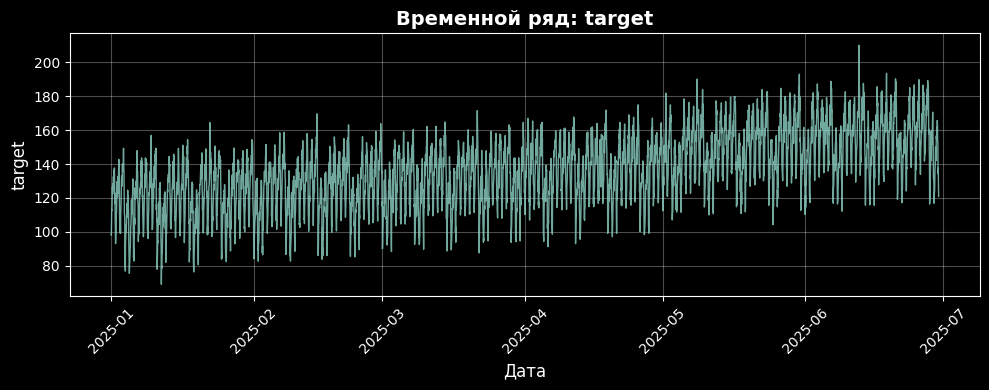

In [6]:
print(f"Число наблюдений: {len(ds)}")

date_min = ds['date'].min()
date_max = ds['date'].max()
date_range = date_max - date_min
print(f"\nДиапазон дат:")
print(f"  Начало: {date_min}")
print(f"  Конец: {date_max}")
print(f"  Продолжительность: {date_range.days} дней")


missing_values = ds.isnull().sum()
print(missing_values)
print(f"\nПроцент пропусков:")
print((missing_values / len(ds) * 100).round(2))


numeric_cols = ds.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    fig, axes = plt.subplots(len(numeric_cols), 1)

    if len(numeric_cols) == 1:
        axes = [axes]

    for i, col in enumerate(numeric_cols):
        axes[i].plot(ds['date'], ds[col], linewidth=1, alpha=0.8)
        axes[i].set_title(f'Временной ряд: {col}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Дата', fontsize=12)
        axes[i].set_ylabel(col, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('artifacts/figures/timeseries_basic_plot.png', dpi=300)
    plt.show()
else:
    print("Числовые колонки для построения графика не найдены")

Видно, что к лету target выше, чем зимой

In [7]:
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

n_total = len(ds)
train_size = int(n_total * train_ratio)
val_size = int(n_total * val_ratio)
test_size = n_total - train_size - val_size

# Границы split'ов
train_end_idx = train_size
val_end_idx = train_size + val_size

# Создаем split'ы
train_ds = ds.iloc[:train_end_idx].copy()
val_ds = ds.iloc[train_end_idx:val_end_idx].copy()
test_ds = ds.iloc[val_end_idx:].copy()

print(f"\nОбщий размер датасета: {n_total} наблюдений")
print(f"\nРазмеры split'ов:")
print(f"  Train: {len(train_ds)} наблюдений ({len(train_ds)/n_total*100:.1f}%)")
print(f"  Validation: {len(val_ds)} наблюдений ({len(val_ds)/n_total*100:.1f}%)")
print(f"  Test: {len(test_ds)} наблюдений ({len(test_ds)/n_total*100:.1f}%)")


Общий размер датасета: 4320 наблюдений

Размеры split'ов:
  Train: 2592 наблюдений (60.0%)
  Validation: 864 наблюдений (20.0%)
  Test: 864 наблюдений (20.0%)



TRAIN:
   Начало: 2025-01-01 00:00:00
   Конец:  2025-04-18 23:00:00
   Индексы: [0 : 2592]

VALIDATION:
   Начало: 2025-04-19 00:00:00
   Конец:  2025-05-24 23:00:00
   Индексы: [2592 : 3456]

TEST:
   Начало: 2025-05-25 00:00:00
   Конец:  2025-06-29 23:00:00
   Индексы: [3456 : 4320]


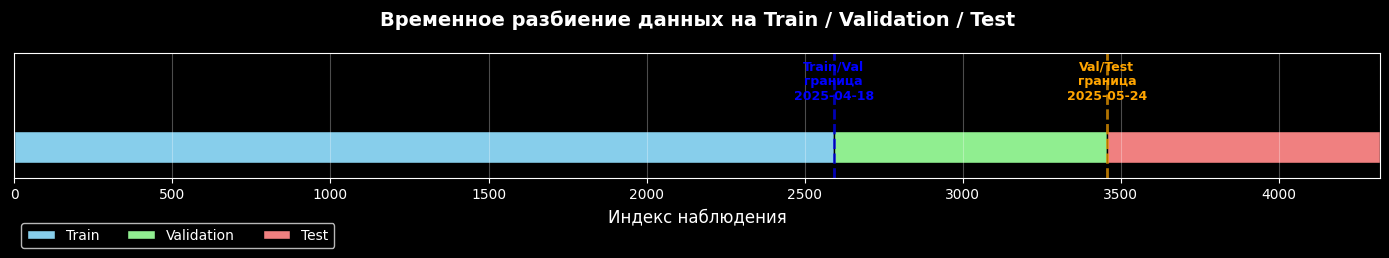

In [8]:
print(f"\nTRAIN:")
print(f"   Начало: {train_ds['date'].min()}")
print(f"   Конец:  {train_ds['date'].max()}")
print(f"   Индексы: [0 : {train_end_idx}]")

print(f"\nVALIDATION:")
print(f"   Начало: {val_ds['date'].min()}")
print(f"   Конец:  {val_ds['date'].max()}")
print(f"   Индексы: [{train_end_idx} : {val_end_idx}]")

print(f"\nTEST:")
print(f"   Начало: {test_ds['date'].min()}")
print(f"   Конец:  {test_ds['date'].max()}")
print(f"   Индексы: [{val_end_idx} : {n_total}]")

# Визуализация границ на временной шкале
fig, ax = plt.subplots(1, 1, figsize=(14, 3))

# Создаем горизонтальную линию с цветными сегментами
ax.barh([0], [train_size], left=[0], height=0.5, color='skyblue', label='Train', edgecolor='black')
ax.barh([0], [val_size], left=[train_size], height=0.5, color='lightgreen', label='Validation', edgecolor='black')
ax.barh([0], [test_size], left=[train_size + val_size], height=0.5, color='lightcoral', label='Test', edgecolor='black')

# Добавляем вертикальные линии на границах
ax.axvline(x=train_size, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=train_size + val_size, color='orange', linestyle='--', linewidth=2, alpha=0.7)

# Подписи границ
ax.text(train_size, 0.7, f'Train/Val\nграница\n{train_ds["date"].max().strftime("%Y-%m-%d")}',
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='blue')
ax.text(train_size + val_size, 0.7, f'Val/Test\nграница\n{val_ds["date"].max().strftime("%Y-%m-%d")}',
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='orange')

ax.set_xlim(0, n_total)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('Индекс наблюдения', fontsize=12)
ax.set_title('Временное разбиение данных на Train / Validation / Test', fontsize=14, fontweight='bold', pad=20)
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.3), ncol=3, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('artifacts/figures/split_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

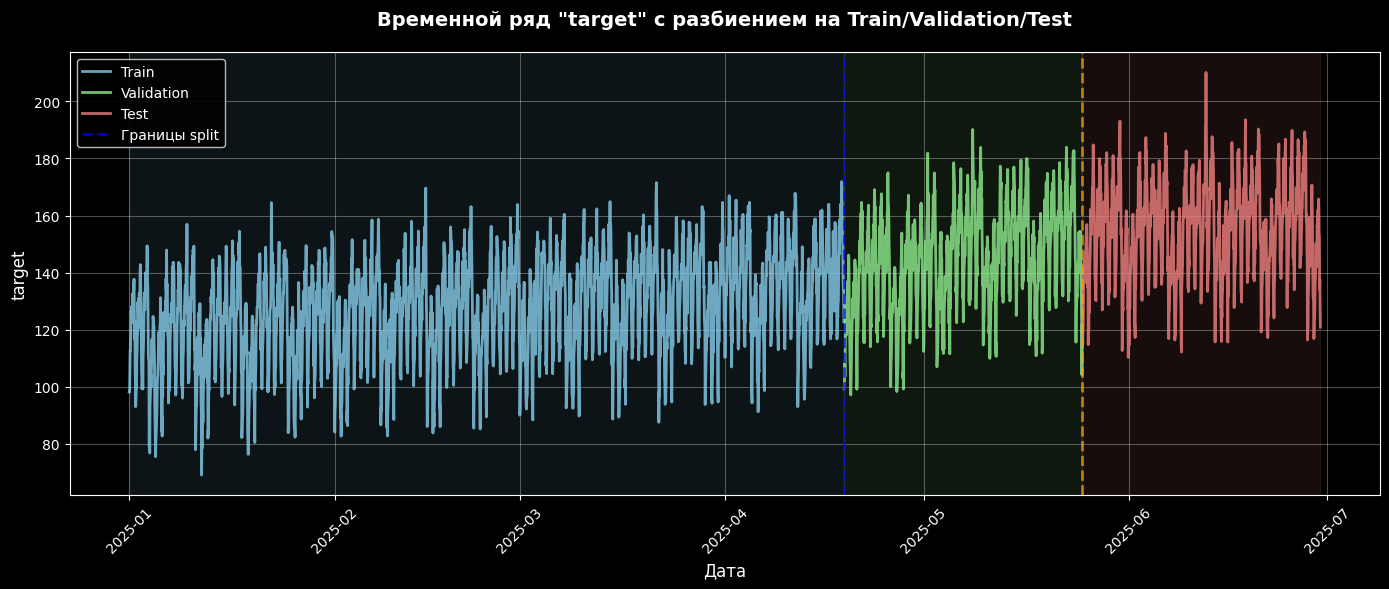

In [9]:
numeric_cols = ds.select_dtypes(include=[np.number]).columns.tolist()
target_col = numeric_cols[0] if numeric_cols else None

if target_col:
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    # Рисуем train
    ax.plot(train_ds['date'], train_ds[target_col],
            label='Train', color='skyblue', linewidth=2, alpha=0.8)

    # Рисуем validation
    ax.plot(val_ds['date'], val_ds[target_col],
            label='Validation', color='lightgreen', linewidth=2, alpha=0.8)

    # Рисуем test
    ax.plot(test_ds['date'], test_ds[target_col],
            label='Test', color='lightcoral', linewidth=2, alpha=0.8)

    # Вертикальные линии на границах
    ax.axvline(x=train_ds['date'].max(), color='blue', linestyle='--',
               linewidth=2, alpha=0.7, label='Границы split')
    ax.axvline(x=val_ds['date'].max(), color='orange', linestyle='--',
               linewidth=2, alpha=0.7)

    # Затенение областей
    ax.axvspan(train_ds['date'].min(), train_ds['date'].max(),
               color='skyblue', alpha=0.1)
    ax.axvspan(val_ds['date'].min(), val_ds['date'].max(),
               color='lightgreen', alpha=0.1)
    ax.axvspan(test_ds['date'].min(), test_ds['date'].max(),
               color='lightcoral', alpha=0.1)

    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel(target_col, fontsize=12)
    ax.set_title(f'Временной ряд "{target_col}" с разбиением на Train/Validation/Test',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('artifacts/figures/series_split.png', dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
split_info = {
    'train_size': train_size,
    'val_size': val_size,
    'test_size': test_size,
    'train_end_idx': train_end_idx,
    'val_end_idx': val_end_idx,
    'train_start_date': str(train_ds['date'].min()),
    'train_end_date': str(train_ds['date'].max()),
    'val_start_date': str(val_ds['date'].min()),
    'val_end_date': str(val_ds['date'].max()),
    'test_start_date': str(test_ds['date'].min()),
    'test_end_date': str(test_ds['date'].max())
}
with open('artifacts/split_info.json', 'w', encoding='utf-8') as f:
    json.dump(split_info, f, indent=2, ensure_ascii=False)

In [11]:
def create_features(ds, is_train=True, scaler=None):
    """
    Создание признаков без утечки из будущего
    """
    ds = ds.copy()
    
    # 1. Lag-признаки (сдвиги)
    ds['lag_1'] = ds['target'].shift(1)
    ds['lag_7'] = ds['target'].shift(7)
    ds['lag_14'] = ds['target'].shift(14)
    
    # 2. Rolling статистики (окно 7)
    ds['rolling_mean_7'] = ds['target'].shift(1).rolling(window=7).mean()
    ds['rolling_std_7'] = ds['target'].shift(1).rolling(window=7).std()
    
    # 3. Календарные признаки
    ds['day_of_week'] = ds['date'].dt.dayofweek  # 0-6 (понедельник-воскресенье)
    ds['day_of_month'] = ds['date'].dt.day
    ds['month'] = ds['date'].dt.month
    ds['quarter'] = ds['date'].dt.quarter
    ds['day_of_year'] = ds['date'].dt.dayofyear
    
    # Циклическое кодирование для day_of_week
    ds['day_of_week_sin'] = np.sin(2 * np.pi * ds['day_of_week'] / 7)
    ds['day_of_week_cos'] = np.cos(2 * np.pi * ds['day_of_week'] / 7)
    
    # Циклическое кодирование для month
    ds['month_sin'] = np.sin(2 * np.pi * ds['month'] / 12)
    ds['month_cos'] = np.cos(2 * np.pi * ds['month'] / 12)
    
    # Признак выходного дня
    ds['is_weekend'] = (ds['day_of_week'] >= 5).astype(int)
    
    return ds

# Создание признаков для train
train_featured = create_features(train_ds, is_train=True)

# Для val и test используем только прошлые данные (чтобы не было утечки)
# Объединяем train и val для создания признаков val
train_val_combined = pd.concat([train_ds, val_ds], ignore_index=True)
train_val_featured = create_features(train_val_combined, is_train=False)
val_featured = train_val_featured.iloc[train_size:].copy()

# Для test объединяем train, val и test
full_combined = pd.concat([train_ds, val_ds, test_ds], ignore_index=True)
full_featured = create_features(full_combined, is_train=False)
test_featured = full_featured.iloc[train_size+val_size:].copy()

# Удаление строк с NaN (появились из-за lag и rolling)
train_featured = train_featured.dropna()
val_featured = val_featured.dropna()
test_featured = test_featured.dropna()

print(f"Train shape: {train_featured.shape}")
print(f"Validation shape: {val_featured.shape}")
print(f"Test shape: {test_featured.shape}")

# Определение признаков
feature_cols = [col for col in train_featured.columns if col not in ['date', 'target']]
print(f"\nFeatures: {feature_cols}")

Train shape: (2578, 17)
Validation shape: (864, 17)
Test shape: (864, 17)

Features: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'day_of_month', 'month', 'quarter', 'day_of_year', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_weekend']


In [12]:
class TimeSeriesDataset(Dataset):
    def __init__(self, features, targets, window_size):
        self.features = features
        self.targets = targets
        self.window_size = window_size

    def __len__(self):
        return len(self.features) - self.window_size

    def __getitem__(self, idx):
        # Окно входных данных
        x = self.features[idx:idx + self.window_size]
        # Целевое значение (следующее после окна)
        y = self.targets[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

def prepare_sequences(ds, feature_cols, window_size, scaler=None, fit_scaler=False):
    features = ds[feature_cols].values
    targets = ds['target'].values

    # Масштабирование
    if fit_scaler:
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
    else:
        if scaler is not None:
            features_scaled = scaler.transform(features)
        else:
            features_scaled = features
    
    # Масштабирование target (опционально)
    target_scaler = StandardScaler()
    if fit_scaler:
        targets_scaled = target_scaler.fit_transform(targets.reshape(-1, 1)).flatten()
    else:
        targets_scaled = targets  # или scaler.transform если есть
    
    dataset = TimeSeriesDataset(features_scaled, targets_scaled, window_size)
    return dataset, scaler, target_scaler

# Параметры
window_size = 14  # размер окна

# Подготовка данных
train_dataset, feature_scaler, target_scaler = prepare_sequences(
    train_featured, feature_cols, window_size, fit_scaler=True
)

val_dataset, _, _ = prepare_sequences(
    val_featured, feature_cols, window_size, scaler=feature_scaler, fit_scaler=False
)

test_dataset, _, _ = prepare_sequences(
    test_featured, feature_cols, window_size, scaler=feature_scaler, fit_scaler=False
)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 81
Validation batches: 27
Test batches: 27


In [13]:


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        gru_out, _ = self.gru(x)
        # Берем последний временной шаг
        out = self.fc(gru_out[:, -1, :])
        return out

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_y)

            total_loss += loss.item()
            predictions.extend(output.cpu().numpy())
            targets.extend(batch_y.cpu().numpy())

    return total_loss / len(loader), np.array(predictions), np.array(targets)

def calculate_metrics(predictions, targets):
    """Расчет метрик"""
    from sklearn.metrics import mean_squared_error, mean_absolute_error

    mse = mean_squared_error(targets, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets, predictions)
    mape = np.mean(np.abs((targets - predictions) / targets)) * 100

    return {
        'RMSE': float(rmse),    # ← Конвертируем в float
        'MSE': float(mse),
        'MAE': float(mae),
        'MAPE': float(mape)
    }

# Обучение модели
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    patience_counter = 0
    training_history = {
        'train_loss': [],
        'val_loss': [],
        'val_metrics': []
    }

    print(f"Training on device: {device}")

    for epoch in range(epochs):
        # Training
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validation
        val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
        val_metrics = calculate_metrics(val_preds.flatten(), val_targets.flatten())

        # Scheduler step
        scheduler.step(val_loss)

        # Logging
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['val_metrics'].append(val_metrics)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Val RMSE: {val_metrics['RMSE']:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_metrics': val_metrics
            }, 'artifacts/best_gru_model.pth')
            print(f"  ✓ Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Save training history
    with open('artifacts/training_history.json', 'w') as f:
        json.dump(training_history, f, indent=2)

    return model, training_history



In [14]:
# Инициализация модели
input_size = len(feature_cols)
model = GRUModel(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)

# Обучение
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=4,
    lr=0.001,
    patience=15
)

Training on device: cpu
Epoch 1/4 | Train Loss: 0.463297 | Val Loss: 21117.711335 | Val RMSE: 145.3903
  ✓ Best model saved!
Epoch 2/4 | Train Loss: 0.153133 | Val Loss: 21143.600514 | Val RMSE: 145.4772
Epoch 3/4 | Train Loss: 0.137600 | Val Loss: 21121.013925 | Val RMSE: 145.4000
Epoch 4/4 | Train Loss: 0.125496 | Val Loss: 21097.121636 | Val RMSE: 145.3183
  ✓ Best model saved!


In [15]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # sMAPE
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}

# ============================================
# B1: Naive Last
# ============================================
def naive_last_forecast(train_df, val_df, test_df):
    last_value = train_df['target'].iloc[-1]

    val_pred = np.full(len(val_df), last_value)
    test_pred = np.full(len(test_df), last_value)

    val_metrics = calculate_metrics(val_df['target'].values, val_pred)
    test_metrics = calculate_metrics(test_df['target'].values, test_pred)

    return {
        'experiment': 'B1_naive_last',
        'val_predictions': val_pred,
        'test_predictions': test_pred,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'best_val_mae': val_metrics['MAE']
    }

# ============================================
# B2: Moving Average
# ============================================
def moving_average_forecast(train_df, val_df, test_df, window=24):
    # Используем скользящее среднее по последним window значениям train
    train_values = train_df['target'].values

    val_predictions = []
    context = list(train_values[-window:])

    for i in range(len(val_df)):
        pred = np.mean(context)
        val_predictions.append(pred)
        # Обновляем контекст (сдвигаем окно)
        context = context[1:] + [pred]

    test_predictions = []
    context = list(train_values[-window:]) + val_predictions

    for i in range(len(test_df)):
        pred = np.mean(context[-window:])
        test_predictions.append(pred)
        context = context[1:] + [pred]

    val_predictions = np.array(val_predictions)
    test_predictions = np.array(test_predictions)

    val_metrics = calculate_metrics(val_df['target'].values, val_predictions)
    test_metrics = calculate_metrics(test_df['target'].values, test_predictions)

    return {
        'experiment': f'B2_moving_average_w{window}',
        'val_predictions': val_predictions,
        'test_predictions': test_predictions,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'best_val_mae': val_metrics['MAE']
    }

# ============================================
# B3: Ridge with Lag Features
# ============================================
def create_lag_features(df, target_col='target', lags=[1, 2, 3, 24, 48],
                        rolling_windows=[6, 12, 24]):
    """Создание лаговых и rolling признаков БЕЗ использования будущего"""
    df = df.copy()

    # Лаговые признаки
    for lag in lags:
        df[f'lag_{lag}'] = df[target_col].shift(lag)

    # Rolling статистики
    for window in rolling_windows:
        df[f'rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window).std()

    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month

    # Cyclical encoding для часа и дня недели
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df

def ridge_lag_forecast(train_df, val_df, test_df):
    # Объединяем для создания признаков
    full_train = pd.concat([train_df, val_df], ignore_index=True)
    full_train = create_lag_features(full_train)

    # Признаки
    feature_cols = [col for col in full_train.columns if col not in ['date', 'target']]

    # Убираем строки с NaN
    train_ready = full_train.iloc[:len(train_df)].dropna()

    X_train = train_ready[feature_cols]
    y_train = train_ready['target']

    # Создаем признаки для validation
    # Для val используем только train данные + предсказания
    full_for_val = pd.concat([train_df, val_df], ignore_index=True)
    full_for_val = create_lag_features(full_for_val)

    # Берем только val часть (после train)
    val_ready = full_for_val.iloc[len(train_df):].dropna()
    X_val = val_ready[feature_cols]
    y_val = val_ready['target']

    # Обучаем Ridge
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    # Предсказания на validation
    val_pred = model.predict(X_val)

    # Для test: нужно предсказывать итеративно
    # Объединяем train + val (с фактическими значениями)
    full_for_test = pd.concat([train_df, val_df, test_df], ignore_index=True)
    full_for_test = create_lag_features(full_for_test)

    test_ready = full_for_test.iloc[len(train_df) + len(val_df):].dropna()
    X_test = test_ready[feature_cols]
    y_test = test_ready['target']

    test_pred = model.predict(X_test)

    val_metrics = calculate_metrics(y_val, val_pred)
    test_metrics = calculate_metrics(y_test, test_pred)

    return {
        'experiment': 'B3_ridge_lag_features',
        'val_predictions': val_pred,
        'test_predictions': test_pred,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'best_val_mae': val_metrics['MAE']
    }



class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def gru_forecast(train_df, val_df, test_df, window_size=48, epochs=50, batch_size=32):
    # Нормализация
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df[['target']])
    val_scaled = scaler.transform(val_df[['target']])
    test_scaled = scaler.transform(test_df[['target']])

    # Создание оконных данных
    def create_windows(data, window_size):
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i:i+window_size, 0])
            y.append(data[i+window_size, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_windows(train_scaled, window_size)
    X_val, y_val = create_windows(
        np.vstack([train_scaled[-window_size:], val_scaled]),
        window_size
    )

    # Reshape для GRU: (batch, seq_len, features)
    X_train = X_train.reshape(-1, window_size, 1)
    X_val = X_val.reshape(-1, window_size, 1)

    # Datasets и DataLoaders
    train_dataset = TimeSeriesDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Модель
    model = GRUModel(input_size=1, hidden_size=64, num_layers=2)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Обучение
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}')

    # Предсказания на validation
    model.eval()
    with torch.no_grad():
        val_pred_scaled = model(torch.FloatTensor(X_val)).numpy().flatten()

    # Для test создаем окна используя train + val
    full_for_test = np.vstack([train_scaled[-window_size:], val_scaled, test_scaled])
    X_test, y_test = create_windows(full_for_test, window_size)
    # Оставляем только test часть
    X_test = X_test[-len(test_df):]
    y_test = y_test[-len(test_df):]

    X_test = X_test.reshape(-1, window_size, 1)

    with torch.no_grad():
        test_pred_scaled = model(torch.FloatTensor(X_test)).numpy().flatten()

    # Обратная нормализация
    val_pred = scaler.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
    test_pred = scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

    # Метрики
    val_metrics = calculate_metrics(val_df['target'].values, val_pred)
    test_metrics = calculate_metrics(test_df['target'].values, test_pred)

    torch.save(model.state_dict(), 'artifacts/best_gru.pt')

    return {
        'experiment': f'R1_gru_forecast_w{window_size}',
        'val_predictions': val_pred,
        'test_predictions': test_pred,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'best_val_mae': val_metrics['MAE'],
        'model': model  # ← Добавьте это
    }

# ============================================
# Запуск всех экспериментов
# ============================================


In [16]:
print("Запуск экспериментов...\n")

results = []

# B1: Naive Last
print("B1: Naive Last")
result_b1 = naive_last_forecast(train_ds, val_ds, test_ds)
results.append(result_b1)
print(f"Validation MAE: {result_b1['val_metrics']['MAE']:.4f}")
print(f"Test MAE: {result_b1['test_metrics']['MAE']:.4f}\n")

# B2: Moving Average (подбираем окно)
print("B2: Moving Average")
best_window = 24  # можно подобрать через grid search
result_b2 = moving_average_forecast(train_ds, val_ds, test_ds, window=best_window)
results.append(result_b2)
print(f"Validation MAE: {result_b2['val_metrics']['MAE']:.4f}")
print(f"Test MAE: {result_b2['test_metrics']['MAE']:.4f}\n")

# B3: Ridge with Lag Features
print("B3: Ridge with Lag Features")
result_b3 = ridge_lag_forecast(train_ds, val_ds, test_ds)
results.append(result_b3)
print(f"Validation MAE: {result_b3['val_metrics']['MAE']:.4f}")
print(f"Test MAE: {result_b3['test_metrics']['MAE']:.4f}\n")


print("R1: GRU Forecast")
result_r1 = gru_forecast(train_ds, val_ds, test_ds, window_size=48, epochs=50, batch_size=32)
results.append(result_r1)
print(f"Validation MAE: {result_r1['val_metrics']['MAE']:.4f}")
print(f"Test MAE: {result_r1['test_metrics']['MAE']:.4f}\n")


print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")

# Сортируем по best_val_mae
results_sorted = sorted(results, key=lambda x: x['best_val_mae'])

for i, result in enumerate(results_sorted, 1):
    print(f"\n{i}. {result['experiment']}")
    print(f"   Val MAE: {result['val_metrics']['MAE']:.4f}")
    print(f"   Val RMSE: {result['val_metrics']['RMSE']:.4f}")
    print(f"   Val MAPE: {result['val_metrics']['MAPE']:.4f}%")
    print(f"   Test MAE: {result['test_metrics']['MAE']:.4f}")

# Лучшая модель
best_model = results_sorted[0]
print(f"\n{'='*50}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model['experiment']}")
print(f"Test MAE: {best_model['test_metrics']['MAE']:.4f}")
print(f"{'='*50}")

# Сохранение в runs.csv
runs_data = []
for result in results:
    run = {
        'experiment': result['experiment'],
        'val_mae': result['val_metrics']['MAE'],
        'val_rmse': result['val_metrics']['RMSE'],
        'val_mape': result['val_metrics']['MAPE'],
        'val_smape': result['val_metrics']['sMAPE'],
        'test_mae': result['test_metrics']['MAE'],
        'test_rmse': result['test_metrics']['RMSE'],
        'test_mape': result['test_metrics']['MAPE'],
        'test_smape': result['test_metrics']['sMAPE'],
        'best_val_mae': result['best_val_mae']
    }
    runs_data.append(run)

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в runs.csv")

# Финальная оценка на test для лучшей модели
print(f"\nФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА TEST для {best_model['experiment']}:")
print(f"MAE: {best_model['test_metrics']['MAE']:.4f}")
print(f"RMSE: {best_model['test_metrics']['RMSE']:.4f}")
print(f"MAPE: {best_model['test_metrics']['MAPE']:.4f}%")
print(f"sMAPE: {best_model['test_metrics']['sMAPE']:.4f}%")

Запуск экспериментов...

B1: Naive Last
Validation MAE: 24.0226
Test MAE: 32.0115

B2: Moving Average
Validation MAE: 15.3852
Test MAE: 14.9256

B3: Ridge with Lag Features
Validation MAE: 4.7593
Test MAE: 5.0095

R1: GRU Forecast
Epoch [10/50], Loss: 0.1143
Epoch [20/50], Loss: 0.1003
Epoch [30/50], Loss: 0.0975
Epoch [40/50], Loss: 0.0933
Epoch [50/50], Loss: 0.0937
Validation MAE: 5.3895
Test MAE: 7.8468

СРАВНЕНИЕ РЕЗУЛЬТАТОВ

1. B3_ridge_lag_features
   Val MAE: 4.7593
   Val RMSE: 6.0503
   Val MAPE: 3.3334%
   Test MAE: 5.0095

2. R1_gru_forecast_w48
   Val MAE: 5.3895
   Val RMSE: 6.9631
   Val MAPE: 3.7450%
   Test MAE: 7.8468

3. B2_moving_average_w24
   Val MAE: 15.3852
   Val RMSE: 18.9722
   Val MAPE: 11.4599%
   Test MAE: 14.9256

4. B1_naive_last
   Val MAE: 24.0226
   Val RMSE: 28.3675
   Val MAPE: 15.7257%
   Test MAE: 32.0115

ЛУЧШАЯ МОДЕЛЬ: B3_ridge_lag_features
Test MAE: 5.0095

Результаты сохранены в runs.csv

ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА TEST для B3_ridge_lag_features:


In [17]:
def save_runs_csv(results, train_df, val_df, test_df, feature_cols, window_size, horizon, seed=42):
    """Сохраняет таблицу результатов всех экспериментов"""

    runs_data = []

    for result in results:
        run = {
            'experiment_id': result['experiment'].split('_')[0],  # B1, B2, B3, R1
            'task': 'forecasting',
            'dataset': 'S12-hw-dataset',
            'seed': seed,
            'split_summary': f"train:{len(train_df)}/val:{len(val_df)}/test:{len(test_df)}",
            'window_size': window_size if 'window_size' in result else (48 if 'gru' in result['experiment'] else None),
            'horizon': horizon,
            'model_summary': result.get('model_summary', result['experiment']),
            'features_summary': f"{len(feature_cols)} features" if feature_cols else None,
            'scaler': 'StandardScaler' if 'scaler' in result else None,
            'optimizer': result.get('optimizer', None),
            'lr': result.get('lr', None),
            'epochs_trained': result.get('epochs_trained', None),
            'best_val_mae': result['val_metrics']['MAE'],
            'best_val_rmse': result['val_metrics']['RMSE'],
            'best_val_mape': result['val_metrics']['MAPE'],
            'test_mae': result['test_metrics']['MAE'],
            'test_rmse': result['test_metrics']['RMSE'],
            'test_mape': result['test_metrics']['MAPE'],
            'notes': result.get('notes', '')
        }
        runs_data.append(run)

    runs_df = pd.DataFrame(runs_data)
    runs_df.to_csv('artifacts/runs.csv', index=False)
    print("✓ runs.csv сохранён")
    return runs_df

# ============================================
# 2. Сохранение best_gru.pt
# ============================================
def save_best_gru_model(model, filepath='artifacts/best_gru.pt'):
    """Сохраняет state_dict лучшей GRU модели"""
    torch.save(model.state_dict(), filepath)
    print(f"✓ best_gru.pt сохранён в {filepath}")

# ============================================
# 3. Сохранение best_gru_config.json
# ============================================
def save_gru_config(config, filepath='artifacts/best_gru_config.json'):
    """Сохраняет конфигурацию лучшей GRU модели"""
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)
    print(f"✓ best_gru_config.json сохранён в {filepath}")

# ============================================
# 4. Визуализация train/val/test split
# ============================================
def save_series_split_plot(train_df, val_df, test_df, target_col='target',
                           filepath='artifacts/figures/series_split.png'):
    """Сохраняет визуализацию разбиения данных"""

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    ax.plot(train_df['date'], train_df[target_col],
            label='Train', color='skyblue', linewidth=2, alpha=0.8)
    ax.plot(val_df['date'], val_df[target_col],
            label='Validation', color='lightgreen', linewidth=2, alpha=0.8)
    ax.plot(test_df['date'], test_df[target_col],
            label='Test', color='lightcoral', linewidth=2, alpha=0.8)

    ax.axvline(x=train_df['date'].max(), color='blue', linestyle='--',
               linewidth=2, alpha=0.7)
    ax.axvline(x=val_df['date'].max(), color='orange', linestyle='--',
               linewidth=2, alpha=0.7)

    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel(target_col, fontsize=12)
    ax.set_title('Временной ряд с разбиением на Train/Validation/Test',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ series_split.png сохранён в {filepath}")

# ============================================
# 5. Сравнение baseline моделей
# ============================================
def save_baselines_compare_plot(results, metric='MAE',
                                filepath='artifacts/figures/baselines_compare.png'):
    """Сохраняет сравнение моделей по одной из метрик"""

    experiments = [r['experiment'] for r in results]
    metrics = [r['val_metrics'][metric] for r in results]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    colors = ['skyblue', 'lightgreen', 'lightcoral', 'plum']
    bars = ax.bar(experiments, metrics, color=colors, edgecolor='black', linewidth=1.5)

    # Добавляем значения на столбцы
    for bar, metric_val in zip(bars, metrics):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{metric_val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xlabel('Эксперимент', fontsize=12)
    ax.set_ylabel(f'Validation {metric}', fontsize=12)
    ax.set_title(f'Сравнение моделей по Validation {metric}',
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    # Подсветка лучшей модели
    best_idx = np.argmin(metrics)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('orange')
    bars[best_idx].set_linewidth(2.5)

    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ baselines_compare.png сохранён в {filepath}")

# ============================================
# 6. Кривые обучения GRU
# ============================================
def save_gru_learning_curves(training_history,
                             filepath='artifacts/figures/gru_learning_curves.png'):
    """Сохраняет кривые обучения GRU"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(training_history['train_loss']) + 1)

    # Loss curve
    axes[0].plot(epochs, training_history['train_loss'],
                 'b-', label='Train Loss', linewidth=2, marker='o', markersize=4)
    axes[0].plot(epochs, training_history['val_loss'],
                 'r-', label='Val Loss', linewidth=2, marker='s', markersize=4)

    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('MSE Loss', fontsize=12)
    axes[0].set_title('Loss по эпохам', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right', framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)

    # MAE curve
    val_mae = [m['MAE'] for m in training_history['val_metrics']]
    axes[1].plot(epochs, val_mae, 'g-', label='Val MAE', linewidth=2, marker='o', markersize=4)

    # Лучшая эпоха
    best_epoch = np.argmin(val_mae) + 1
    best_mae = min(val_mae)
    axes[1].axvline(x=best_epoch, color='red', linestyle='--',
                    label=f'Best: Epoch {best_epoch}', linewidth=2, alpha=0.7)
    axes[1].scatter([best_epoch], [best_mae], color='red', s=100, zorder=5)

    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('MAE по эпохам', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper right', framealpha=0.9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ gru_learning_curves.png сохранён в {filepath}")

# ============================================
# 7. Прогноз лучшей модели на test
# ============================================
def save_best_forecast_test_plot(test_df, predictions, target_col='target',
                                 filepath='artifacts/figures/best_forecast_test.png'):
    """Сохраняет график факта и прогноза лучшей модели на test"""

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    dates = test_df['date'].values
    actual = test_df[target_col].values

    ax.plot(dates, actual, 'b-', label='Actual', linewidth=2, alpha=0.8)
    ax.plot(dates, predictions, 'r--', label='Predicted', linewidth=2, alpha=0.8)

    # Ошибка
    error = np.abs(actual - predictions)
    ax.fill_between(dates, actual - error, actual + error,
                    color='gray', alpha=0.2, label='Error Range')

    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel(target_col, fontsize=12)
    ax.set_title('Факт vs Прогноз лучшей модели на Test',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    # Добавляем метрики
    mae = np.mean(error)
    rmse = np.sqrt(np.mean(error**2))
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100

    textstr = f'MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ best_forecast_test.png сохранён в {filepath}")


In [18]:
runs_df = save_runs_csv(results, train_ds, val_ds, test_ds,
                        feature_cols, window_size=48, horizon=1, seed=42)

feature_cols = [col for col in train_featured.columns if col not in ['date', 'target']]

# 2. Сохраняем лучшую GRU модель

# 3. Сохраняем конфиг GRU
gru_config = {
    'architecture': 'GRU',
    'input_size': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': 48,
    'batch_size': 32,
    'learning_rate': 0.001,
    'seed': 42,
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'epochs_trained': len(history['train_loss']),
    'best_val_mae': min([m['MAE'] for m in history['val_metrics']])
}
save_gru_config(gru_config)

# 4. Сохраняем все графики
save_series_split_plot(train_ds, val_ds, test_ds)
save_baselines_compare_plot(results, metric='MAE')
save_gru_learning_curves(history)
best_result = min(results, key=lambda x: x['best_val_mae'])
best_predictions = best_result['test_predictions']
best_gru_model = best_result.get('model', None)
save_best_forecast_test_plot(test_ds, best_predictions)

✓ runs.csv сохранён
✓ best_gru_config.json сохранён в artifacts/best_gru_config.json
✓ series_split.png сохранён в artifacts/figures/series_split.png
✓ baselines_compare.png сохранён в artifacts/figures/baselines_compare.png
✓ gru_learning_curves.png сохранён в artifacts/figures/gru_learning_curves.png
✓ best_forecast_test.png сохранён в artifacts/figures/best_forecast_test.png
